What do i want to analyse?

1. The prevalence of the different tactcis by: model, board type, contract type
2. which tactics were associated with the highest / lowest contract acceptance rate
3. which tactics were associated with the highest / lowest scores for that player


In [ ]:
import json
import numpy as np
import pandas as pd
import pandas as pd

import ast
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import bootstrap
from matplotlib.lines import Line2D

from analysis.format_results import DEFAULT_FONT_SIZE, MODEL_ORDER, BUCKET_ORDER, CONTRACT_ORDER, FULL_DF, format_data

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)

mpl.rcParams.update({
    "font.size": DEFAULT_FONT_SIZE,         
    "axes.titlesize": DEFAULT_FONT_SIZE,
    "axes.labelsize": DEFAULT_FONT_SIZE,
    "legend.fontsize": DEFAULT_FONT_SIZE,
    "xtick.labelsize": DEFAULT_FONT_SIZE,
    "ytick.labelsize": DEFAULT_FONT_SIZE,
    "font.family":'monospace'
})

TACTICS = [
    ("extreme_opening_demand", "Extreme Opening"),
    ("incremental_concessions", "Incremental Concessions"),
    ("power_exploitation", "Power Exploitation"),
    ("detailed_tile_by_tile_calculation", "Tile-by-Tile Calculation"),
    ("deadline_urgency_pressure", "Deadline Pressure"),
    ("take_it_or_leave_it_ultimatum", "Take it or Leave it"),
    ("appeal_to_fairness_norms", "Appeal to Fairness"),
    ("mutual_verification", "Mutual Verification"),
    ("refusal_to_engage", "Refusal / Non-Engagement"),
    ("guilt_or_social_pressure", "Guilt / Social Pressure"),
]

GROUP_ORDERS = {
    "Model": MODEL_ORDER,
    "Board Type": BUCKET_ORDER,
    "Contract Type": CONTRACT_ORDER,
}



def load_negotiation_classifications(filepath: str) -> pd.DataFrame:
    records = []
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            row = json.loads(line)
            
            record = {
                'filepath': row.get('filepath'),
                'Model': row.get('model'),
                'Board Type': row.get('board_type'),
                'grid_id': row.get('grid_id'),
                'Contract Type': row.get('contract_type'),
                'pay4partner': row.get('pay4partner'),
                'agreement_status': row.get('agreement_status'),
                'error': row.get('error'),
            }

            tactic_display = {raw: display for raw, display in TACTICS}

            tactics = row.get('tactics') or {}
            for tactic_name, tactic_data in tactics.items():
                display_name = tactic_display.get(tactic_name, tactic_name)
                observed_user = tactic_data.get('observed_for_user')
                observed_assistant = tactic_data.get('observed_for_assistant')
                record[f'{display_name}_P_Blue'] = observed_user
                record[f'{display_name}_P_Red'] = observed_assistant
                record[f'{display_name}'] = bool(observed_user or observed_assistant)
                record[f'{display_name}_P_Blue_evidence'] = tactic_data.get('evidence_user')
                record[f'{display_name}_P_Red_evidence'] = tactic_data.get('evidence_assistant')
            
            records.append(record)

    df = pd.DataFrame(records)

    df["Contract Type"] = df["Contract Type"].replace({
        "tile_with_judge_implementation": "NL-Trading",
        "strict": "Prog-Trading",
        "contract_for_finishing": "Prog-Points"
        })
    
    models = df["Model"].str.partition("-")
    same_model = models[0] == models[2]
    df["Model"] = np.where(same_model, models[0], df["Model"])
    model_map = {
        "FOUR_1": "GPT-4.1",
        "HAIKU_4_5": "Haiku-4.5",
        "LLAMA_MAVERICK": "LLaMA Maverick",
        "LLAMA_SCOUT": "LLaMA Scout",
        "QWEN_3_235B": "Qwen-3-235B",
        "QWEN_3_30B": "Qwen-3-30B"
        }
    df["Model"] = df["Model"].map(model_map).fillna(df["Model"])
    df["Board Type"] = df["Board Type"].replace({
        "Independent_Both_have_optimal_paths": "Independent",
        "Mutual_Dependency": "Mutually Dependent",
        "Needy_Player_Blue": "Asymmetric"
    })
    df['run_id'] = df['filepath'].str.extract(r'(\d{8}_\d{6}_\d{6}_[a-f0-9]+)')

    
    return df

In [22]:
df = load_negotiation_classifications('analysis/contract_negotiation_analysis/negotiation_classifications.jsonl')


In [23]:
df

,filepath,Model,Board Type,grid_id,Contract Type,pay4partner,agreement_status,error,Extreme Opening_P_Blue,Extreme Opening_P_Red,Extreme Opening,Extreme Opening_P_Blue_evidence,Extreme Opening_P_Red_evidence,Incremental Concessions_P_Blue,Incremental Concessions_P_Red,Incremental Concessions,Incremental Concessions_P_Blue_evidence,Incremental Concessions_P_Red_evidence,Power Exploitation_P_Blue,Power Exploitation_P_Red,Power Exploitation,Power Exploitation_P_Blue_evidence,Power Exploitation_P_Red_evidence,Tile-by-Tile Calculation_P_Blue,Tile-by-Tile Calculation_P_Red,Tile-by-Tile Calculation,Tile-by-Tile Calculation_P_Blue_evidence,Tile-by-Tile Calculation_P_Red_evidence,Deadline Pressure_P_Blue,Deadline Pressure_P_Red,Deadline Pressure,Deadline Pressure_P_Blue_evidence,Deadline Pressure_P_Red_evidence,Take it or Leave it_P_Blue,Take it or Leave it_P_Red,Take it or Leave it,Take it or Leave it_P_Blue_evidence,Take it or Leave it_P_Red_evidence,Appeal to Fairness_P_Blue,Appeal to Fairness_P_Red,Appeal to Fairness,Appeal to Fairness_P_Blue_evidence,Appeal to Fairness_P_Red_evidence,Mutual Verification_P_Blue,Mutual Verification_P_Red,Mutual Verification,Mutual Verification_P_Blue_evidence,Mutual Verification_P_Red_evidence,Refusal / Non-Engagement_P_Blue,Refusal / Non-Engagement_P_Red,Refusal / Non-Engagement,Refusal / Non-Engagement_P_Blue_evidence,Refusal / Non-Engagement_P_Red_evidence,Guilt / Social Pressure_P_Blue,Guilt / Social Pressure_P_Red,Guilt / Social Pressure,Guilt / Social Pressure_P_Blue_evidence,Guilt / Social Pressure_P_Red_evidence,run_id
0,public_logs/reduced_config_runs/QWEN_3_235B-QW...,Qwen-3-235B,Asymmetric,122,NL-Trading,True,True,None,False,False,False,,,False,False,False,,,False,False,False,,,True,True,True,"My best path: (0,0) → (0,1) [B] → (1,1) [B] → ...","I am at (0, 0), goal at (3, 3). ... Path A: (0...",False,False,False,,,False,True,True,,I will only agree if you accept all terms.,False,False,False,,,True,True,True,You're right — I need to correct my understand...,You are correct — I misread my own path earlier.,False,False,False,,,False,False,False,,,20260120_235914_241945_c8a7295b
1,public_logs/reduced_config_runs/QWEN_3_235B-QW...,Qwen-3-235B,Asymmetric,140,Prog-Points,True,True,None,False,True,True,,"Therefore, I propose the following contract: -...",False,False,False,,,False,True,True,,This means you need me more than I need you. Y...,True,True,True,"My optimal path: (0,0) → (1,0) → (2,0) → (3,0)...","I plan to reach (3,3) via the path: (0, 0) → (...",False,False,False,,,False,True,True,,I will not accept less than 20 points from you...,False,False,False,,,True,True,True,"Let’s be clear: My optimal path: (0,0) → (1,0)...","I see that we both start at (0, 0) and share t...",False,False,False,,,False,False,False,,,20260121_092459_483480_1b211e7a
2,public_logs/reduced_config_runs/QWEN_3_235B-QW...,Qwen-3-235B,Asymmetric,140,Prog-Trading,False,True,None,False,False,False,,,False,False,False,,,False,True,True,,I do not need to cooperate with you to reach m...,True,True,True,"Turn: 1: (3, 1): You give me a B (3, 1): I gi...","This path requires: - (0, 1): R - (1, 1): R .....",False,False,False,,,False,True,True,,"If you do not accept this, I can simply go alo...",False,False,False,,,True,False,True,Do you pay to enter the goal tile? Yes — you m...,,False,False,False,,,False,False,False,,,20260121_092223_298607_1bb1ea0c
3,public_logs/reduced_config_runs/QWEN_3_235B-QW...,Qwen-3-235B,Asymmetric,140,Prog-Trading,True,True,None,False,False,False,,,False,False,False,,,True,True,True,"You, on the other hand, cannot reach your goal...",I do not need your help ... you need me to cov...,True,True,True,"Turn: 1: (1,0): You give me a B (2,0): You gi...","My best path ... (0,0) → (0,1) [R] → (1,1) [R]...",False,False,False,,,False,False,False,,,False,False,False,,,True,True,True,I have specified coverage for every tile where...,Wait — let's double-check: do I really have en...,False,False,False,,,False,False,

In [63]:
def plot_tactic_heatmap(df, group_by: str = "Model", use_either: bool = True, metric_col: str = None, deg_freedom=0):
    tactic_display_names = [display for _, display in TACTICS]
    
    if use_either:
        cols = tactic_display_names
    else:
        cols = [f'{t}_P_Blue' for t in tactic_display_names] + \
               [f'{t}_P_Red' for t in tactic_display_names]

    if metric_col:
        # For each tactic, compute mean of metric_col where tactic == 1
        extra_cols = cols + [group_by, metric_col]
        numeric_df = df[extra_cols].copy()
        numeric_df[cols] = numeric_df[cols].apply(pd.to_numeric, errors='coerce')
        numeric_df[metric_col] = pd.to_numeric(numeric_df[metric_col], errors='coerce')

        records = []
        for grp, grp_df in numeric_df.groupby(group_by):
            row = {}
            for tactic in cols:
                mask = grp_df[tactic] == 1
                row[tactic] = grp_df.loc[mask, metric_col].mean() if mask.sum() > 0 else float('nan')
            records.append({group_by: grp, **row})
        heatmap_data = pd.DataFrame(records).set_index(group_by)
        cbar_label = f'Avg {metric_col}'
        vmin, vmax = None, None  # let seaborn auto-scale
    else:
        # Default: frequency of tactic occurrence
        numeric_df = df[cols + [group_by]].copy()
        numeric_df[cols] = numeric_df[cols].apply(pd.to_numeric, errors='coerce')
        heatmap_data = numeric_df.groupby(group_by)[cols].mean() * 100
        cbar_label = '% of negotiations'
        vmin, vmax = 0, 100

    if group_by in GROUP_ORDERS:
        ordered = [g for g in GROUP_ORDERS[group_by] if g in heatmap_data.index]
        heatmap_data = heatmap_data.loc[ordered]

    col_order = heatmap_data.mean(axis=0).sort_values(ascending=False).index
    heatmap_data = heatmap_data[col_order].T

    fig, ax = plt.subplots(figsize=(len(cols) * 0.9 + 2, len(heatmap_data) * 0.6 + 2))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=f".{deg_freedom}f",
        cmap="Greens",
        vmin=vmin, vmax=vmax,
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': cbar_label}
    )
    title = f'Avg {metric_col} by Tactic & {group_by}' if metric_col else f'Tactic Usage by {group_by} (%)'
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel(group_by)
    ax.set_ylabel('Tactic')
    plt.xticks(rotation=35, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

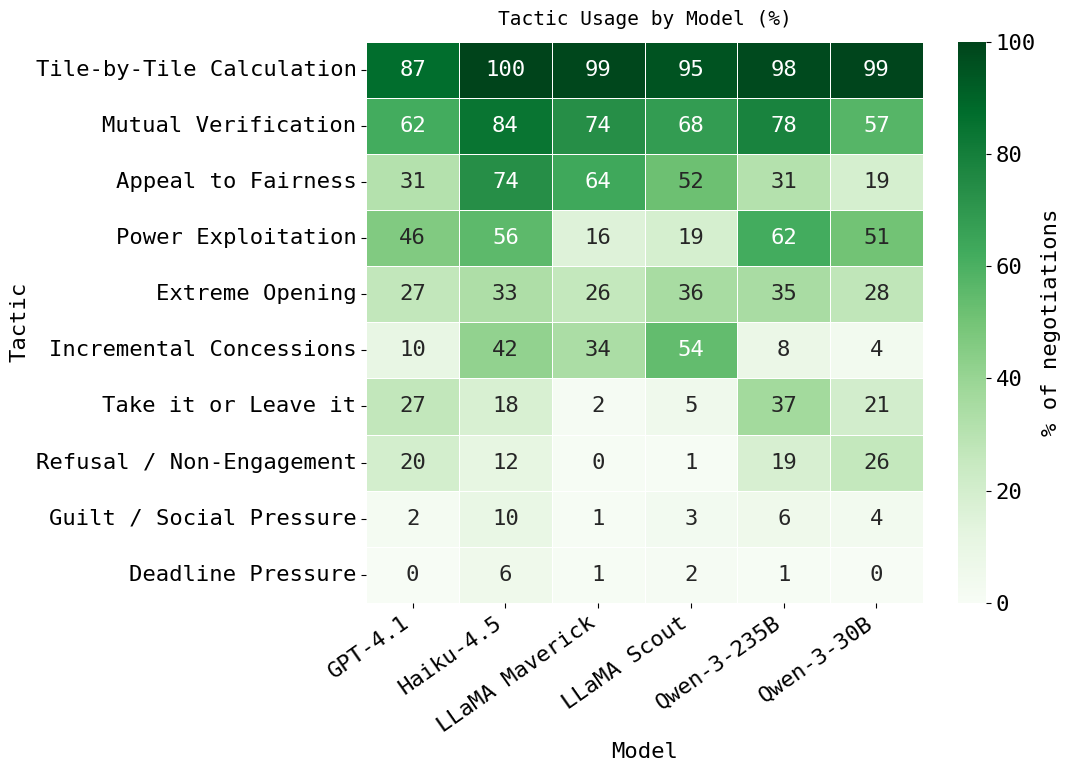

In [64]:
# Usage:
plot_tactic_heatmap(df, group_by="Model")


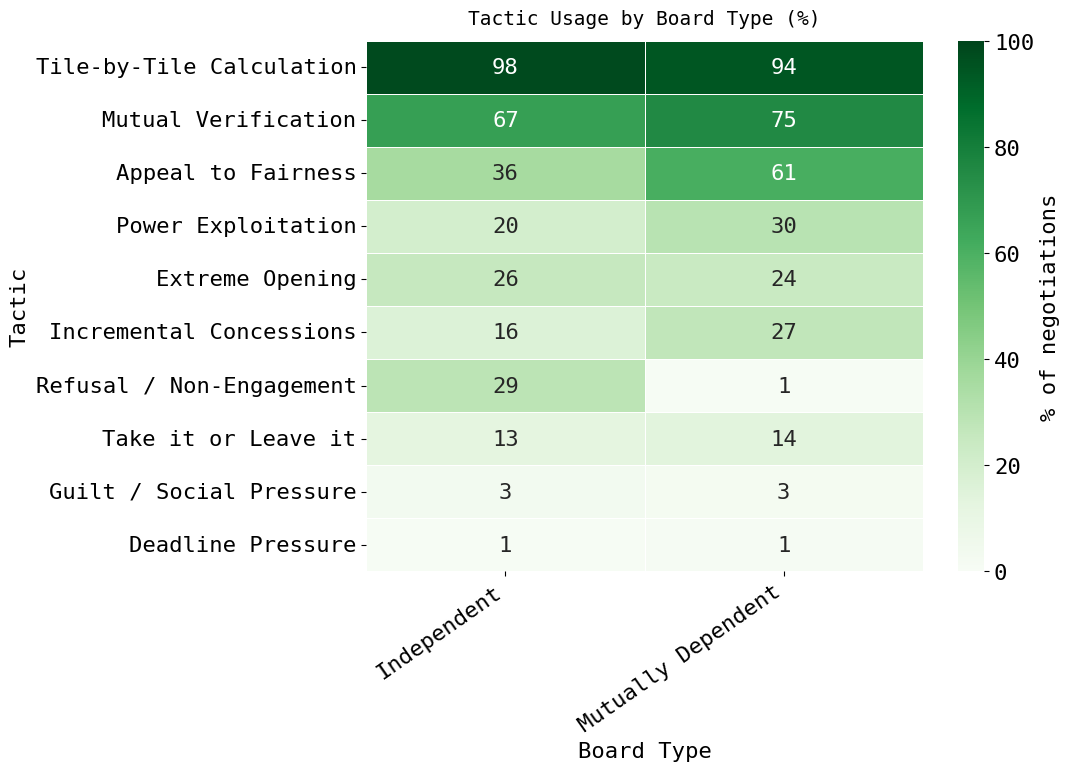

In [62]:
plot_tactic_heatmap(df, group_by="Board Type")

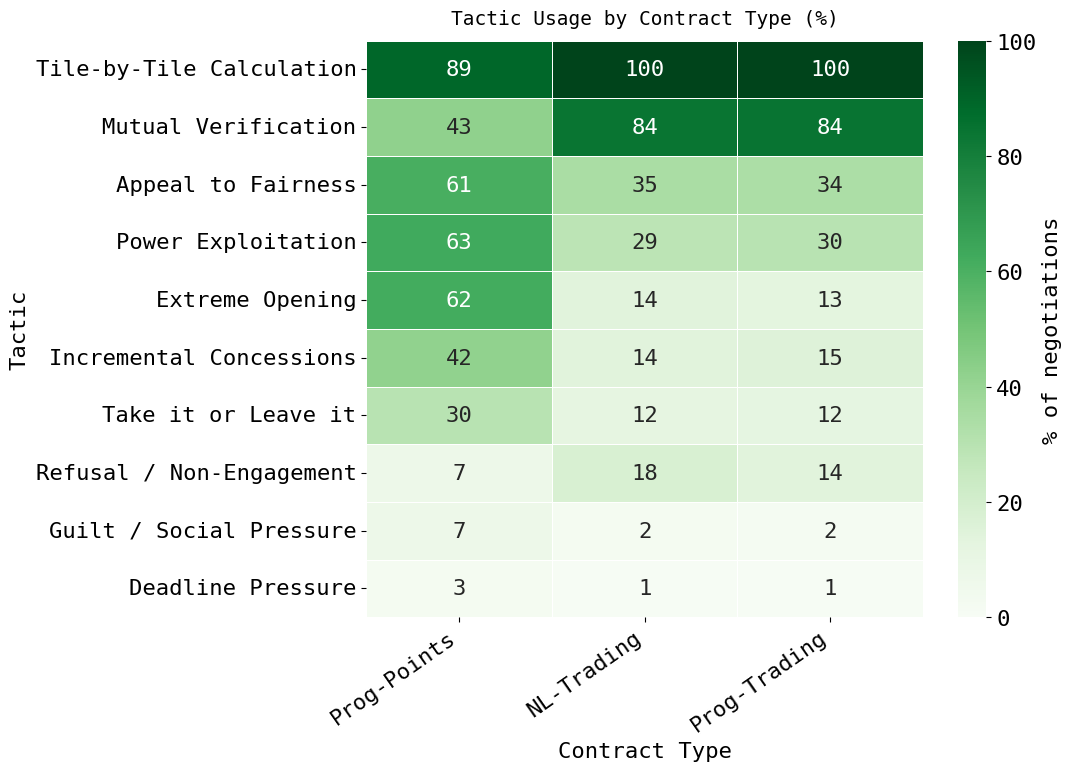

In [54]:
plot_tactic_heatmap(df, group_by="Contract Type")


2. which tactics were associated with the highest / lowest contract acceptance rate


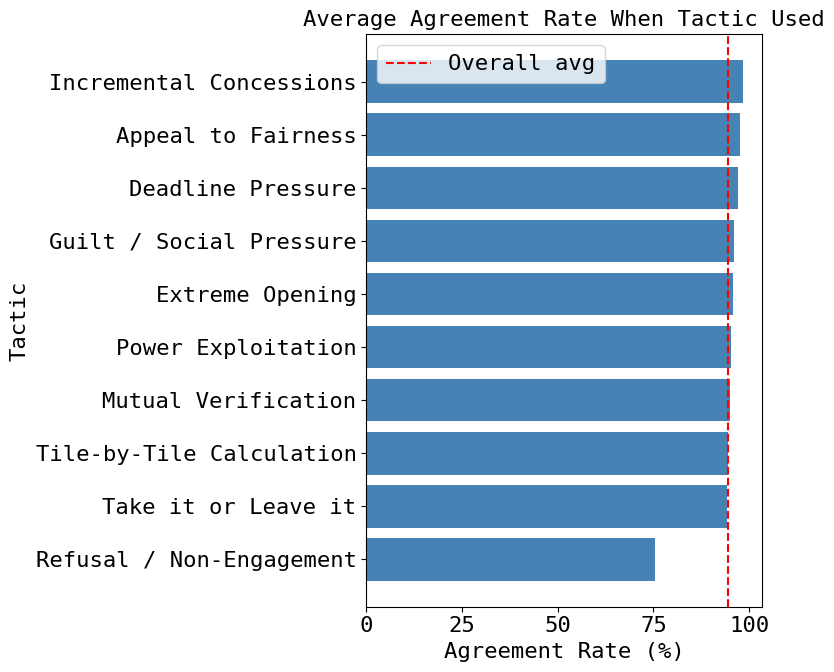

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_agreement_by_tactic(df):
    tactic_display_names = [display for _, display in TACTICS]
    
    # Convert agreement_status to numeric (1 = agreed, 0 = not)
    df = df.copy()
    df['agreement_numeric'] = pd.to_numeric(df['agreement_status'], errors='coerce')
    # If agreement_status is string like 'Agreement'/'No Agreement', map it:
    if df['agreement_numeric'].isna().all():
        df['agreement_numeric'] = df['agreement_status'].map({'Agreement': 1, 'No Agreement': 0})

    results = {}
    for tactic in tactic_display_names:
        col = pd.to_numeric(df[tactic], errors='coerce')
        mask = col == 1
        if mask.sum() > 0:
            results[tactic] = df.loc[mask, 'agreement_numeric'].mean() * 100

    result_df = pd.Series(results).sort_values(ascending=True)  # ascending for horizontal bar

    fig, ax = plt.subplots(figsize=(8, len(result_df) * 0.5 + 2))
    bars = ax.barh(result_df.index, result_df.values, color='steelblue')
    ax.axvline(df['agreement_numeric'].mean() * 100, color='red', linestyle='--', label='Overall avg')
    ax.set_xlabel('Agreement Rate (%)')
    ax.set_ylabel('Tactic')
    ax.set_title('Average Agreement Rate When Tactic Used')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_agreement_by_tactic(df)

3. which tactics were associated with the highest / lowest scores for that player


In [29]:
result_df = pd.concat([
    format_data(FULL_DF, p4p=True),
    format_data(FULL_DF, p4p=False),
])

LLaMA Maverick has 320 rows.
Qwen-3-235B has 320 rows.
Qwen-3-30B has 320 rows.
LLaMA Scout has 320 rows.
GPT-4.1 has 320 rows.
Haiku-4.5 has 320 rows.
Formatted data with 6 unique model pairs,  1920 total rows
LLaMA Maverick has 320 rows.
Qwen-3-235B has 320 rows.
Qwen-3-30B has 320 rows.
LLaMA Scout has 320 rows.
GPT-4.1 has 320 rows.
Haiku-4.5 has 320 rows.
Formatted data with 6 unique model pairs,  1920 total rows


In [36]:
merged_df = pd.merge(df, result_df, left_on=["Model", "Board Type", "Contract Type", "pay4partner", "grid_id", "run_id"], right_on=["Model", "Board Type", "Contract Type", "Pay4Partner", "Grid ID",  "Run ID"])[
    df.columns.tolist() + ["net_tiles_promised_to_receive_from_contract_P-Blue", "net_points_for_completion_promised_to_P-Blue", "net_points_for_completion_promised_to_P-Red", "net_tiles_promised_to_receive_from_contract_P-Red"]]

In [38]:
merged_df.columns

Index(['filepath', 'Model', 'Board Type', 'grid_id', 'Contract Type',
       'pay4partner', 'agreement_status', 'error', 'Extreme Opening_P_Blue',
       'Extreme Opening_P_Red', 'Extreme Opening',
       'Extreme Opening_P_Blue_evidence', 'Extreme Opening_P_Red_evidence',
       'Incremental Concessions_P_Blue', 'Incremental Concessions_P_Red',
       'Incremental Concessions', 'Incremental Concessions_P_Blue_evidence',
       'Incremental Concessions_P_Red_evidence', 'Power Exploitation_P_Blue',
       'Power Exploitation_P_Red', 'Power Exploitation',
       'Power Exploitation_P_Blue_evidence',
       'Power Exploitation_P_Red_evidence', 'Tile-by-Tile Calculation_P_Blue',
       'Tile-by-Tile Calculation_P_Red', 'Tile-by-Tile Calculation',
       'Tile-by-Tile Calculation_P_Blue_evidence',
       'Tile-by-Tile Calculation_P_Red_evidence', 'Deadline Pressure_P_Blue',
       'Deadline Pressure_P_Red', 'Deadline Pressure',
       'Deadline Pressure_P_Blue_evidence', 'Deadline Pressure_

In [40]:
tactic_display_names = [display for _, display in TACTICS]

# Create one df per player
df_red = merged_df.copy()
df_red['Player'] = 'P-Red'
for tactic in tactic_display_names:
    df_red[tactic] = df_red[f'{tactic}_P_Red']
df_red['net_tiles_promised_to_receive_from_contract'] = df_red['net_tiles_promised_to_receive_from_contract_P-Red']
df_red['net_points_for_completion_promised'] = df_red['net_points_for_completion_promised_to_P-Red']

df_blue = merged_df.copy()
df_blue['Player'] = 'P-Blue'
for tactic in tactic_display_names:
    df_blue[tactic] = df_blue[f'{tactic}_P_Blue']
df_blue['net_tiles_promised_to_receive_from_contract'] = df_blue['net_tiles_promised_to_receive_from_contract_P-Blue']
df_blue['net_points_for_completion_promised'] = df_blue['net_points_for_completion_promised_to_P-Blue']

cols_to_drop = [col for col in merged_df.columns if any(col.endswith(suffix) for suffix in ['_P_Red', '_P_Blue', 'P-Red', 'P-Blue'])]
df_red = df_red.drop(columns=cols_to_drop)
df_blue = df_blue.drop(columns=cols_to_drop)

# Stack into one long df
player_df = pd.concat([df_red, df_blue], ignore_index=True)
player_df.head()

,filepath,Model,Board Type,grid_id,Contract Type,pay4partner,agreement_status,error,Extreme Opening,Extreme Opening_P_Blue_evidence,Extreme Opening_P_Red_evidence,Incremental Concessions,Incremental Concessions_P_Blue_evidence,Incremental Concessions_P_Red_evidence,Power Exploitation,Power Exploitation_P_Blue_evidence,Power Exploitation_P_Red_evidence,Tile-by-Tile Calculation,Tile-by-Tile Calculation_P_Blue_evidence,Tile-by-Tile Calculation_P_Red_evidence,Deadline Pressure,Deadline Pressure_P_Blue_evidence,Deadline Pressure_P_Red_evidence,Take it or Leave it,Take it or Leave it_P_Blue_evidence,Take it or Leave it_P_Red_evidence,Appeal to Fairness,Appeal to Fairness_P_Blue_evidence,Appeal to Fairness_P_Red_evidence,Mutual Verification,Mutual Verification_P_Blue_evidence,Mutual Verification_P_Red_evidence,Refusal / Non-Engagement,Refusal / Non-Engagement_P_Blue_evidence,Refusal / Non-Engagement_P_Red_evidence,Guilt / Social Pressure,Guilt / Social Pressure_P_Blue_evidence,Guilt / Social Pressure_P_Red_evidence,run_id,Player,net_tiles_promised_to_receive_from_contract,net_points_for_completion_promised
0,public_logs/reduced_config_runs/QWEN_3_235B-QW...,Qwen-3-235B,Asymmetric,122,NL-Trading,True,True,None,False,,,False,,,False,,,True,"My best path: (0,0) → (0,1) [B] → (1,1) [B] → ...","I am at (0, 0), goal at (3, 3). ... Path A: (0...",False,,,True,,I will only agree if you accept all terms.,False,,,True,You're right — I need to correct my understand...,You are correct — I misread my own path earlier.,False,,,False,,,20260120_235914_241945_c8a7295b,P-Red,0,0
1,public_logs/reduced_config_runs/QWEN_3_235B-QW...,Qwen-3-235B,Asymmetric,140,Prog-Points,True,True,None,True,,"Therefore, I propose the following contract: -...",False,,,True,,This means you need me more than I need you. Y...,True,"My optimal path: (0,0) → (1,0) → (2,0) → (3,0)...","I plan to reach (3,3) via the path: (0, 0) → (...",False,,,True,,I will not accept less than 20 points from you...,False,,,True,"Let’s be clear: My optimal path: (0,0) → (1,0)...","I see that we both start at (0, 0) and share t...",False,,,False,,,20260121_092459_483480_1b211e7a,P-Red,0,20
2,public_logs/reduced_config_runs/QWEN_3_235B-QW...,Qwen-3-235B,Asymmetric,140,Prog-Trading,False,True,None,False,,,False,,,True,,I do not need to cooperate with you to reach m...,True,"Turn: 1: (3, 1): You give me a B (3, 1): I gi...","This path requires: - (0, 1): R - (1, 1): R .....",False,,,True,,"If you do not accept this, I can simply go alo...",False,,,False,Do you pay to enter the goal tile? Yes — you m...,,False,,,False,,,20260121_092223_298607_1bb1ea0c,P-Red,1,0
3,public_logs/reduced_config_runs/QWEN_3_235B-QW...,Qwen-3-235B,Asymmetric,140,Prog-Trading,True,True,None,False,,,False,,,True,"You, on the other hand, cannot reach your goal...",I do not need your help ... you need me to cov...,True,"Turn: 1: (1,0): You give me a B (2,0): You gi...","My best path ... (0,0) → (0,1) [R] → (1,1) [R]...",False,,,False,,,False,,,True,I have specified coverage for every tile where...,Wait — let's double-check: do I really have en...,False,,,False,,,20260121_092356_673987_9ddb9405,P-Red,1,0
4,public_logs/reduced_config_runs/QWEN_3_235B-QW...,Qwen-3-235B,Asymmetric,122,NL-Trading,False,True,None,False,,,False,,,True,I can give you that R — but only if I gain a b...,"you have 0×R, so you cannot pay for (2,3) ... ...",True,"Currently, I plan to take this path: (0,0) → (...","I need to reach (3, 3), and my optimal path is...",False,,,False,,,False,,,True,I will only agree if all tiles where I need a ...,"(0,1): You give me a B (0,2): You give me a B...",False,,,False,,,20260120_235852_790505_0153da0c,P-Red,0,0


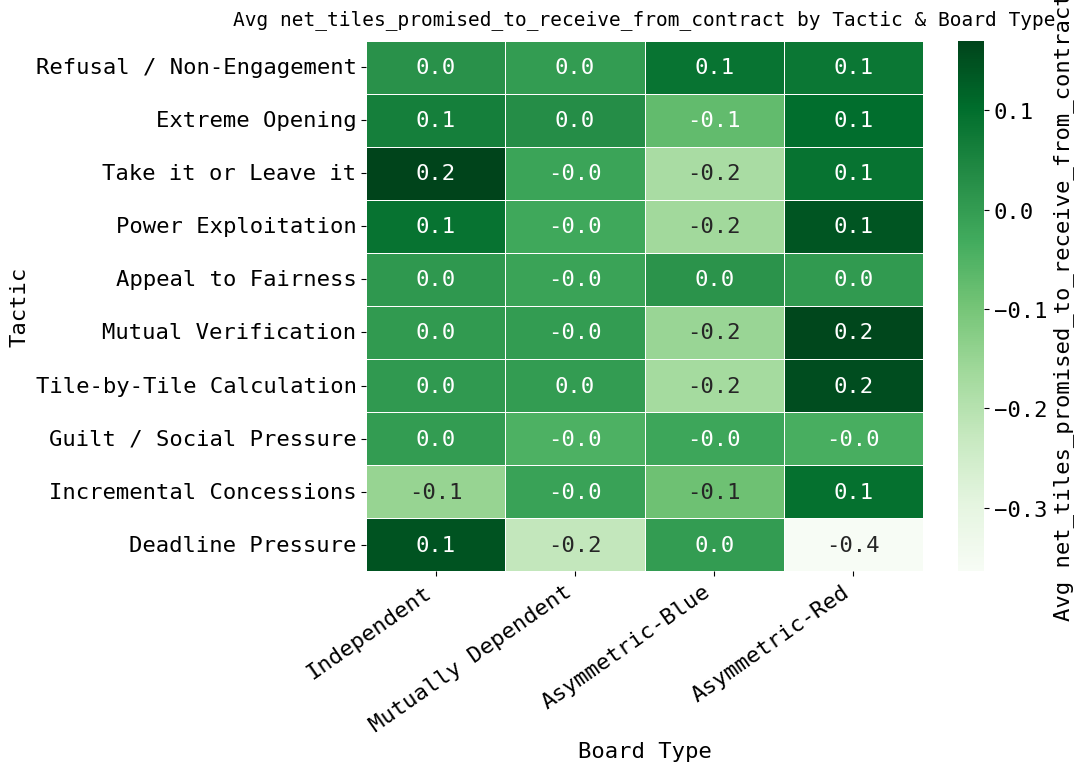

In [65]:
player_df['Board Type'] = player_df.apply(
    lambda row: f"Asymmetric-{row['Player'].split('-')[1]}" 
    if row['Board Type'] == 'Asymmetric' 
    else row['Board Type'],
    axis=1
)

BUCKET_ORDER = ["Independent", "Mutually Dependent", "Asymmetric-Blue", "Asymmetric-Red"]
GROUP_ORDERS = {
    "Model": MODEL_ORDER,
    "Board Type": BUCKET_ORDER,
    "Contract Type": CONTRACT_ORDER,
}
plot_tactic_heatmap(player_df, group_by="Board Type", metric_col="net_tiles_promised_to_receive_from_contract", deg_freedom=1)


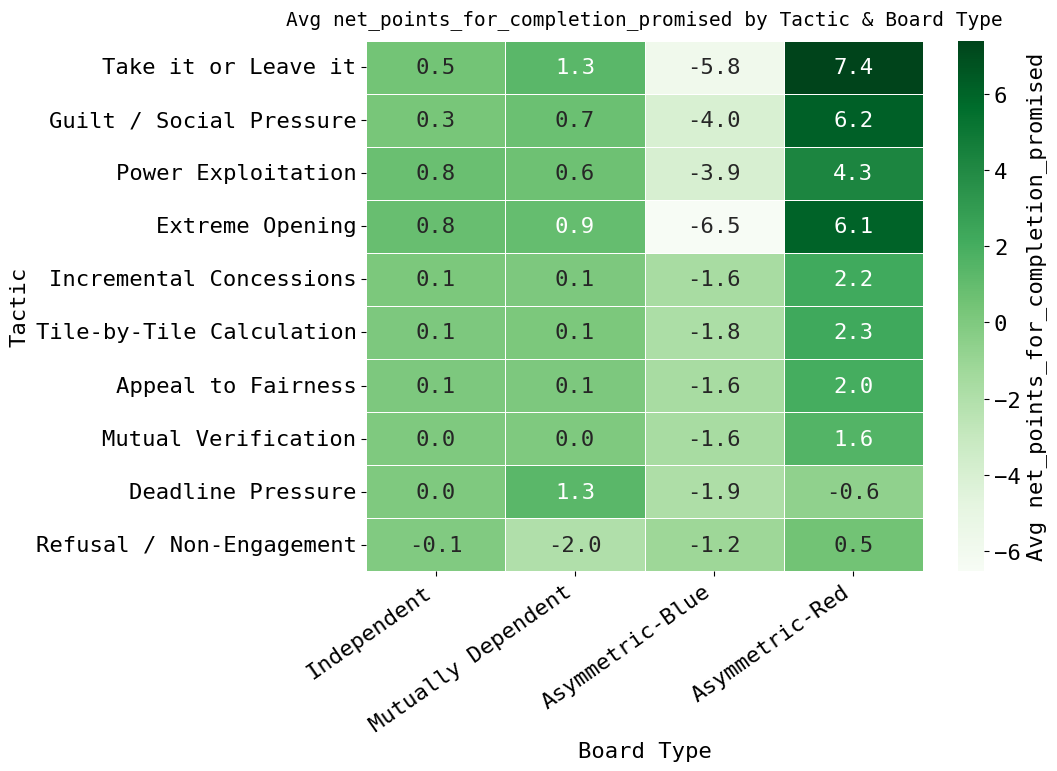

In [66]:
plot_tactic_heatmap(player_df, group_by="Board Type", metric_col="net_points_for_completion_promised", deg_freedom=1)